# Figure 1: Coupled Lorenz Coupling Sweep

**Paper Figure 1** --- Binding score as a function of coupling strength for two diffusively coupled Lorenz systems.

Expected shape: unimodal. Score rises from zero (uncoupled, independent attractors) to a peak around coupling ~0.3-0.5 (maximal topological novelty in the joint space), then decreases as coupling approaches 1.0 (synchronization collapse --- joint attractor degenerates toward marginals).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from att.config import set_seed
from att.synthetic import coupled_lorenz
from att.binding import BindingDetector

rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['font.size'] = 11
rcParams['font.family'] = 'serif'

In [2]:
set_seed(42)

coupling_values = np.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
n_steps = 8000
transient = 1000
subsample = 500

scores = []
h0_scores = []
h1_scores = []

for c in coupling_values:
    print(f"coupling={c:.2f} ... ", end="", flush=True)
    ts_x, ts_y = coupled_lorenz(n_steps=n_steps, coupling=c, seed=42)
    X = ts_x[transient:, 0]
    Y = ts_y[transient:, 0]
    
    det = BindingDetector(max_dim=1, baseline="max", embedding_quality_gate=False)
    det.fit(X, Y, subsample=subsample, seed=42)
    
    score = det.binding_score()
    features = det.binding_features()
    
    scores.append(score)
    h0_scores.append(features[0]['total_persistence'])
    h1_scores.append(features[1]['total_persistence'])
    print(f"score={score:.2f} (H0={features[0]['total_persistence']:.2f}, H1={features[1]['total_persistence']:.2f})")

scores = np.array(scores)
h0_scores = np.array(h0_scores)
h1_scores = np.array(h1_scores)

coupling=0.00 ... 

score=184.19 (H0=164.59, H1=19.60)
coupling=0.05 ... 

score=252.93 (H0=221.24, H1=31.69)
coupling=0.10 ... 

score=257.21 (H0=223.75, H1=33.47)
coupling=0.20 ... 

score=219.28 (H0=189.21, H1=30.07)
coupling=0.30 ... 

...

score=246.21 (H0=218.25, H1=27.96)
coupling=0.50 ... 

score=191.40 (H0=166.38, H1=25.02)
coupling=0.60 ... 

score=240.52 (H0=219.02, H1=21.50)
coupling=0.80 ... 

score=170.17 (H0=150.98, H1=19.20)
coupling=1.00 ... 

score=89.31 (H0=71.91, H1=17.40)


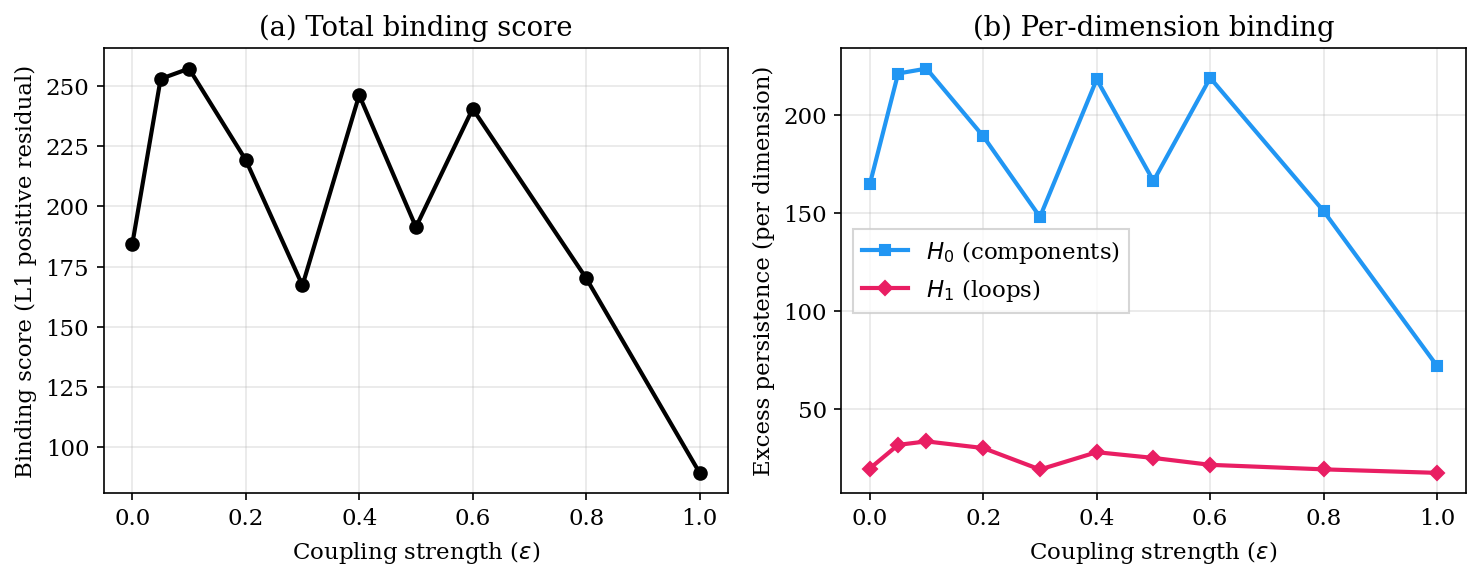

Saved to figures/fig1_coupling_sweep.{pdf,png}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: total binding score
ax = axes[0]
ax.plot(coupling_values, scores, 'ko-', linewidth=2, markersize=6)
ax.set_xlabel('Coupling strength ($\\epsilon$)')
ax.set_ylabel('Binding score (L1 positive residual)')
ax.set_title('(a) Total binding score')
ax.grid(True, alpha=0.3)

# Right: per-dimension breakdown
ax = axes[1]
ax.plot(coupling_values, h0_scores, 's-', color='#2196F3', linewidth=2, markersize=5, label='$H_0$ (components)')
ax.plot(coupling_values, h1_scores, 'D-', color='#E91E63', linewidth=2, markersize=5, label='$H_1$ (loops)')
ax.set_xlabel('Coupling strength ($\\epsilon$)')
ax.set_ylabel('Excess persistence (per dimension)')
ax.set_title('(b) Per-dimension binding')
ax.legend(frameon=True, fancybox=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../figures/fig1_coupling_sweep.pdf', bbox_inches='tight')
fig.savefig('../figures/fig1_coupling_sweep.png', bbox_inches='tight')
plt.show()
print("Saved to figures/fig1_coupling_sweep.{pdf,png}")